<a href="https://colab.research.google.com/github/ShankarReddy70/Deep-Learning/blob/master/DL_Task_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--2026-03-26 09:35:09--  https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/zidane.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168949 (165K) [image/jpeg]
Saving to: ‘zidane.jpg’

zidane.jpg          100%[===================>] 164.99K  --.-KB/s    in 0.02s   

2026-03-26 09:35:09 (6.91 MB/s) - ‘zidane.jpg’ saved [168949/168949]


0: 384x640 2 persons, 1 tie, 251.1ms
Speed: 9.1ms preprocess, 251.1ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)
Time taken: 0.33s


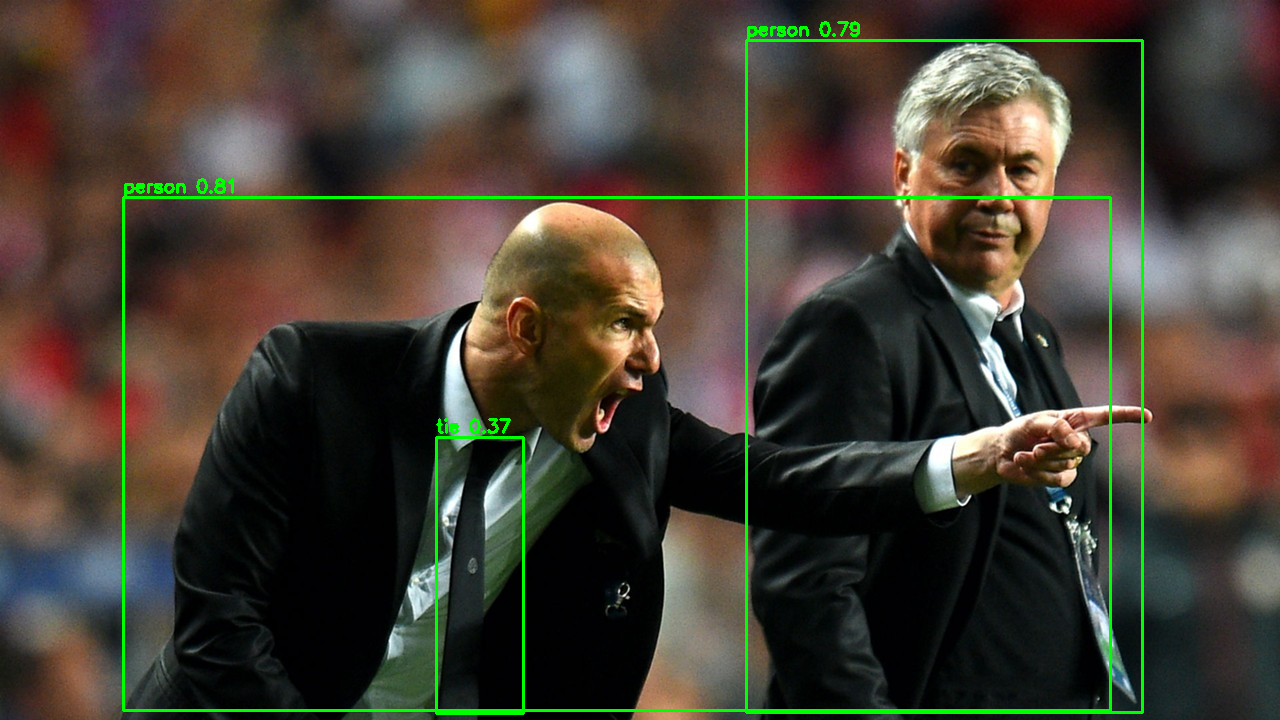

Saved as output.jpg


In [3]:
# 1. Install ultralytics
!pip install -q ultralytics

import numpy as np
import os
import cv2
import time
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# 2. Download sample image if not exists
img_path = "zidane.jpg" # Changed from dog.jpg to zidane.jpg
if not os.path.exists(img_path):
    print(f"Downloading {img_path}...")
    !wget https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/zidane.jpg # Updated URL to a working sample image

# Verify download after wget attempt
if not os.path.exists(img_path):
    raise Exception(f"Error: Failed to download {img_path}. Please check the URL and internet connection.")

# 3. Load YOLOv8 model
model = YOLO("yolov8n.pt")

# 4. Read image
image = cv2.imread(img_path)
if image is None:
    raise Exception(f"Error: Image {img_path} loaded as None. It might be corrupted or not a valid image file.")

# 5. Predict
start = time.time()
results = model(image)[0]
end = time.time()

print(f"Time taken: {end - start:.2f}s")

# 6. Get class names directly from model (no need coco.names file)
labels = model.names

# 7. Draw results
for box in results.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    conf = float(box.conf[0])
    cls = int(box.cls[0])

    label = f"{labels[cls]} {conf:.2f}"

    # Draw box
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Put label
    cv2.putText(image, label, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# 8. Show image
cv2_imshow(image)

# 9. Save output
cv2.imwrite("output.jpg", image)
print("Saved as output.jpg")